# The naive LSTM
Here we will set up the basic LSTM that predicts electricity prices based on electricity price history. This model will be a simple LSTM followed by a linear layer. The system remembers some information about the electricity price of the previous days and outputs the electricity price for the next day. This is a naive approach, more refined approaches will include weather forecast data (and possibly also weekends and holidays) to more accurately predict the electricity price

In [365]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim



## Importing the data
First, we import the data. We also split it up into training and evaluation data

In [366]:
from datetime import datetime, timezone, timedelta
import csv

infile  = open("price_data.csv", "r", encoding="utf8")
reader = csv.reader(infile)
entire_data = []
winter_time = timezone(timedelta(hours=4))

for line in reader:
    try:
        time_object= datetime.utcfromtimestamp(int(line[0])/1000)
        month = float(time_object.month)
        day = float(time_object.day)
        try:
            if float(time_object.hour) == hour: #in case hours are listed double ignore the second one
                continue
        except NameError:
            pass
        hour = float(time_object.hour)
        price = float(line[1])
    except ValueError:
        continue
    try:
        last_day = entire_data[-1][0][1]
    except:
        entire_data.append([[month, day,price]])
        continue
    if last_day != day:
        entire_data.append([[month, day,price]]) # for the LSTM I need to have a 3-dimensional object
    else:
        entire_data[-1][0].append(price)
print("last hour: ", hour)
print("first day: ", entire_data[0])
print("second day: ", entire_data[1])

entire_data= entire_data[1:-1]#exclude the first and last days so every day has 24 hours of data
cut_day = len(entire_data) *2 // 3 
training_data = torch.tensor(entire_data[:cut_day])
evaluation_data = torch.tensor(entire_data[cut_day:])

last hour:  21.0
first day:  [[1.0, 3.0, -0.01, -0.07, -1.05, -1.0, 0.32, 37.55, 88.76, 122.93, 110.17, 93.38, 90.73, 82.37, 80.9, 80.99, 98.05, 123.51, 148.49, 138.0, 117.64, 117.71, 95.95, 105.68, 95.26, 103.7]]
second day:  [[1.0, 4.0, 108.27, 105.92, 103.41, 102.71, 114.23, 156.91, 182.64, 178.91, 190.0, 189.88, 182.42, 182.46, 179.59, 179.0, 180.93, 166.69, 189.88, 184.94, 178.99, 156.12, 140.92, 137.92, 97.56, 105.31]]


In [367]:
max_price = 0.0
for line in training_data:
    for elem in line[0][2:]:
        if elem >max_price:
            max_price = float(elem)
print("Most expensive:",max_price)

Most expensive: 936.280029296875


## Preliminaries
Imports and some basic tools

The sliding window function for when we iterate through the dataset

In [368]:
from itertools import islice
from collections import deque
def sliding_window(iterable, n):
    "Collect data into overlapping fixed-length chunks or blocks. - from the itertools website"
    # sliding_window('ABCDEFG', 3) → ABC BCD CDE DEF EFG
    iterator = iter(iterable)
    window = deque(islice(iterator, n - 1), maxlen=n)
    for x in iterator:
        window.append(x)
        yield tuple(window)

the normalization so all our values are between -1 and 1

In [369]:
len(torch.tensor([[1,2],[2,3]]))

2

In [370]:
def normalize(tensor):
    result=[]
    for line in list(tensor):
        lin_elem = line[0]
        month = lin_elem[0]/12
        day = lin_elem[1]/31
        prices = list(lin_elem[2:] /max_price)
        day_info = [month]+[day]+prices
        result.append(torch.stack([torch.stack(day_info)])) #The output will be a list of tensors
    return result
def de_normalize(tensor):
    return max_price*tensor

## Defining and training the actual model
The model is a basic LSTM that takes 26 inputs (month, day, 24 prices for 24 hours) and turns it into a hidden state. Then a linear model turns it into 24 outputs (prices for the next day)

In [371]:

class LSTM_predictor(nn.Module):
    def __init__(self, source_dim, hidden_dim, target_size):
        super(LSTM_predictor, self).__init__()
        self.hidden_dim = hidden_dim
        self.pre_processing = nn.Linear(source_dim,source_dim)
        self.lstm = nn.LSTM(source_dim, hidden_dim)
        self.hidden2predict = nn.Linear(hidden_dim, target_size)
    def forward(self, input):
        pre_processed = self.pre_processing(input)
        lstm_out , _ = self.lstm(pre_processed) 
        prediction = self.hidden2predict(lstm_out)
        return prediction

Instantiating the model

In [372]:
SLIDING_WINDOW_LENGTH = 14
HIDDEN_DIMENSION = 10


model = LSTM_predictor(26, HIDDEN_DIMENSION, 24)
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

training_data_normalized = normalize(training_data)

In [373]:
training_data_normalized[0:2]

[tensor([[0.0833, 0.1290, 0.1156, 0.1131, 0.1104, 0.1097, 0.1220, 0.1676, 0.1951,
          0.1911, 0.2029, 0.2028, 0.1948, 0.1949, 0.1918, 0.1912, 0.1932, 0.1780,
          0.2028, 0.1975, 0.1912, 0.1667, 0.1505, 0.1473, 0.1042, 0.1125]]),
 tensor([[0.0833, 0.1613, 0.1039, 0.0903, 0.0805, 0.0845, 0.1012, 0.1059, 0.1080,
          0.1384, 0.1211, 0.1009, 0.1048, 0.1022, 0.1034, 0.1146, 0.1276, 0.1466,
          0.1582, 0.1494, 0.1450, 0.1281, 0.1048, 0.1268, 0.1065, 0.1066]])]

## First Training
Below the model gets trained. We will later train again with different hyperparameters to obtain better results

In [374]:
EPOCH_NUMBER = 10
for epoch in range(EPOCH_NUMBER): 
    print("Epoch: "+str(epoch+1)+"/"+str(EPOCH_NUMBER))
    for data in sliding_window(training_data_normalized, SLIDING_WINDOW_LENGTH):
        training_line = torch.stack(data[:-1])
        result_line = torch.stack(data)[1:,:,2:]
        model.zero_grad()
        prediction  = model(training_line)
        loss = loss_function(prediction, result_line)
        loss.backward()
        optimizer.step()
print("Finished")

Epoch: 1/10
Epoch: 2/10
Epoch: 3/10
Epoch: 4/10
Epoch: 5/10
Epoch: 6/10
Epoch: 7/10
Epoch: 8/10
Epoch: 9/10
Epoch: 10/10
Finished


# Stupid test
This is a stupid test, because it is done on training data. This is a bad test, since models normally perform much better on training data than on test data. We will see though, that our model is so bad that it can't even predict training data.

In [375]:
NUMBER_PREVIOUS_DAYS = 14
OFFSET = 1  #Use offset at least 1, otherwise weird last day effects come up

stupid_test = torch.stack(training_data_normalized[-NUMBER_PREVIOUS_DAYS-OFFSET-1:-OFFSET-1])
stupid_solution = training_data[-NUMBER_PREVIOUS_DAYS-OFFSET:-OFFSET]

with torch.no_grad():
    print("still normalized",model(stupid_test))
    stupid_test_result = de_normalize(model(stupid_test))
print("normalized result",stupid_test_result)
print("solution",stupid_solution)
print("THROUGH THE DAYS")
for i in range(NUMBER_PREVIOUS_DAYS):
    print(stupid_test_result[i][0],stupid_solution[i,-1,2:])

still normalized tensor([[[0.0950, 0.0927, 0.0978, 0.1241, 0.1143, 0.1244, 0.1362, 0.1552,
          0.1426, 0.1372, 0.1274, 0.0770, 0.1108, 0.1210, 0.1080, 0.1545,
          0.1845, 0.1601, 0.2085, 0.1481, 0.1255, 0.1082, 0.1303, 0.1198]],

        [[0.0922, 0.0955, 0.0930, 0.1133, 0.1106, 0.1295, 0.1439, 0.1485,
          0.1272, 0.1204, 0.1143, 0.0890, 0.1006, 0.1061, 0.1281, 0.1494,
          0.1849, 0.1724, 0.1893, 0.1415, 0.1178, 0.1153, 0.1202, 0.1078]],

        [[0.0997, 0.1012, 0.0967, 0.1138, 0.1178, 0.1379, 0.1544, 0.1519,
          0.1279, 0.1205, 0.1166, 0.1011, 0.1035, 0.1072, 0.1422, 0.1534,
          0.1922, 0.1865, 0.1847, 0.1446, 0.1221, 0.1217, 0.1217, 0.1088]],

        [[0.0994, 0.0985, 0.0948, 0.1145, 0.1178, 0.1391, 0.1610, 0.1575,
          0.1241, 0.1145, 0.1149, 0.1072, 0.1024, 0.1017, 0.1493, 0.1487,
          0.1915, 0.1924, 0.1842, 0.1416, 0.1166, 0.1249, 0.1209, 0.1058]],

        [[0.1030, 0.1000, 0.0962, 0.1171, 0.1215, 0.1415, 0.1651, 0.1609,
         

The day is  tensor([ 1., 18.])
The day is  tensor([ 1., 19.])
The day is  tensor([ 1., 20.])
The day is  tensor([ 1., 21.])
The day is  tensor([ 1., 22.])
The day is  tensor([ 1., 23.])
The day is  tensor([ 1., 24.])


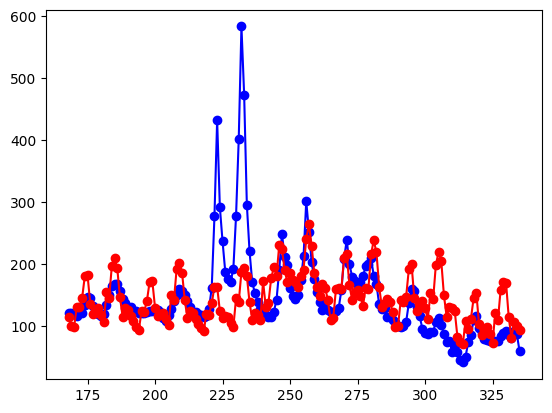

In [376]:
import matplotlib.pyplot as plt
 
PLOT_DAYS_AHEAD=7

# put the data for plotting into lists
hour_list = []
prediction_list = []
actual_list = []
for day in range(NUMBER_PREVIOUS_DAYS-PLOT_DAYS_AHEAD, NUMBER_PREVIOUS_DAYS):
    for hour in range(24):
        hour_list.append(24*day+hour)
    actual_list = actual_list + list(stupid_solution[day,-1,2:])
    print("The day is ", stupid_solution[day,-1,:2])
    prediction_list = prediction_list + list(stupid_test_result[day][0])
# Create the line plot
plt.plot(hour_list, actual_list, color='blue', marker='o', linestyle='-', label = "Real prices")
plt.plot(hour_list, prediction_list, color='red', marker='o', linestyle='-', label = "Predicted prices")

# Display the graph
plt.show()

As we can see, the model still okay, but not good, even when tested on training data. Let's do a proper test with test data that is separate from training data. One way the model should be improved is by including weather forecast data and the weekday.

# Evaluating on separate data

In [377]:
import math
SLIDING_WINDOW_EVAL = 15

def evaluate_model_on_dataset(eval_dataset,the_model):
    eval_dataset_normalized = torch.stack(normalize(eval_dataset))
    mean_off = 0
    for data in sliding_window(eval_dataset_normalized, SLIDING_WINDOW_EVAL+1):
        prediction = the_model(torch.stack(data[:-1])) # evaluate on the data minus the last day
        prediction_de_normalized = de_normalize(prediction[-1][0])
        actual_value = de_normalize(data[-1][0][2:])
        #print("Prediction: ",prediction_de_normalized)
        #print("Actual: ", actual_value)
        how_off = list(prediction_de_normalized - actual_value)
        mean_off_today = 0
        for i in range(24):
            mean_off_today += abs(float(how_off[i]))/24
        mean_off += mean_off_today / (len(eval_dataset_normalized)-SLIDING_WINDOW_EVAL)
    return mean_off
    
off = evaluate_model_on_dataset(evaluation_data,model)
print(off)

36.84891948951222


Let's look at the trivial model that assumes that every day is like the day before

In [378]:
def trivial_model(input_tensor):
    output_tensor = []
    for day in input_tensor:
        output_tensor.append(torch.stack([day[0,2:]]))
    return torch.stack(output_tensor)

mean_abs_off_trivial = evaluate_model_on_dataset(evaluation_data,trivial_model)
print(mean_abs_off_trivial)

26.649759496632928


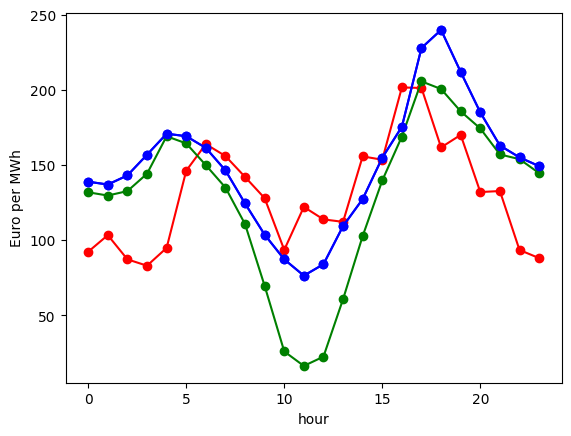

In [379]:
def draw_model(eval_dataset,the_model,offset=0,coloring='red'):
    eval_dataset_normalized = torch.stack(normalize(eval_dataset))
    mean_square_off = 0
    data = eval_dataset_normalized[-SLIDING_WINDOW_EVAL-offset:-offset]
    prediction = the_model(data[:-1]) # evaluate on the data minus the last day
    prediction_de_normalized = de_normalize(prediction[-1][0])
    actual_value = de_normalize(data[-1][0][2:])
    plt.plot(prediction_de_normalized.detach().numpy(),marker='o',label='predicted data',color=coloring)
    plt.plot(actual_value.detach().numpy(),marker='o',label='predicted data',color='blue')
    plt.ylabel("Euro per MWh")
    plt.xlabel("hour")

i = 3
draw_model(evaluation_data,model,offset=i)
draw_model(evaluation_data,trivial_model,offset=i,coloring='green')

# Hyperparameter tuning
Let's use our evaluation function to play around with the model and the training

In [380]:
SLIDING_WINDOW_LENGTH = 21
HIDDEN_DIMENSION = 21
SLIDING_WINDOW_EVAL = 21



model = LSTM_predictor(26, HIDDEN_DIMENSION, 24)
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
training_data_normalized = normalize(training_data)

EPOCH_NUMBER = 30

mean_off = evaluate_model_on_dataset(evaluation_data,model)
print("Mean absolute error:",mean_off)
for epoch in range(EPOCH_NUMBER): 
    print("Epoch: "+str(epoch+1)+"/"+str(EPOCH_NUMBER))
    for data in sliding_window(training_data_normalized, SLIDING_WINDOW_LENGTH):
        training_line = torch.stack(data[:-1])
        result_line = torch.stack(data)[1:,:,2:]
        model.zero_grad()
        prediction  = model(training_line)
        loss = loss_function(prediction, result_line)
        loss.backward()
        optimizer.step()
    mean_off = evaluate_model_on_dataset(evaluation_data,model)
    print("Mean absolute error:",mean_off)
print("Finished")

Mean absolute error: 145.36980678224225
Epoch: 1/30
Mean absolute error: 39.56335741554789
Epoch: 2/30
Mean absolute error: 38.84951516834484
Epoch: 3/30
Mean absolute error: 38.20398592993228
Epoch: 4/30
Mean absolute error: 37.671385779552146
Epoch: 5/30
Mean absolute error: 37.276015156854655
Epoch: 6/30
Mean absolute error: 36.95584260398125
Epoch: 7/30
Mean absolute error: 36.664504122187516
Epoch: 8/30
Mean absolute error: 36.39563545942897
Epoch: 9/30
Mean absolute error: 36.150840660527166
Epoch: 10/30
Mean absolute error: 35.93277616682549
Epoch: 11/30
Mean absolute error: 35.74145867161298
Epoch: 12/30
Mean absolute error: 35.57874453400147
Epoch: 13/30
Mean absolute error: 35.44155770894763
Epoch: 14/30
Mean absolute error: 35.33174363506177
Epoch: 15/30
Mean absolute error: 35.24438628986426
Epoch: 16/30
Mean absolute error: 35.18515368191872
Epoch: 17/30
Mean absolute error: 35.15648158982193
Epoch: 18/30
Mean absolute error: 35.16296662451167
Epoch: 19/30
Mean absolute er

In [381]:
print("Mean absolute error of model")
mean_abs_off = evaluate_model_on_dataset(evaluation_data,model)
print(mean_abs_off)
print("Mean absolute error of trivial model")
mean_abs_off_trivial = evaluate_model_on_dataset(evaluation_data,trivial_model)
print(mean_abs_off_trivial)

Mean absolute error of model
36.321843898724715
Mean absolute error of trivial model
26.626481568002244


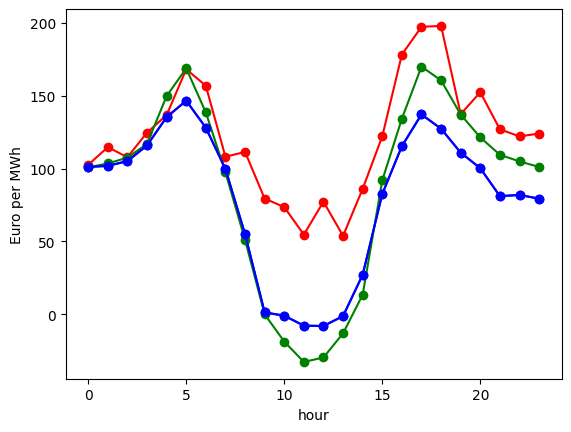

In [382]:
i = 120
draw_model(evaluation_data,model,offset=i)
draw_model(evaluation_data,trivial_model,offset=i,coloring='green')

As we can see, our prediction is still worse than the trivial model. Thus we will include the trivial model in our network

# Adding a same as yesterday component
Unfortunately, the trivial model predicting the price to be the same as yesterday still outperforms our model. Let's build that into our model that it takes this into account. We implement that by giving the linear layer that does the final prediction both the output from the LSTM and the raw data from the previous day.

In [383]:

class LSTM_predictor_improved(nn.Module):
    def __init__(self, source_dim, hidden_dim, target_size):
        super(LSTM_predictor_improved, self).__init__()
        self.hidden_dim = hidden_dim
        self.pre_processing = nn.Linear(source_dim,source_dim)
        self.lstm = nn.LSTM(source_dim, hidden_dim)
        self.hidden2predict = nn.Linear(hidden_dim+source_dim-2, target_size)
    def forward(self, input):
        pre_processed = self.pre_processing(input)
        lstm_out , _ = self.lstm(pre_processed)
        prediction_in = torch.cat((lstm_out, input[:,:,2:]), dim=-1)
        prediction = self.hidden2predict(prediction_in)
        return prediction

Now let's train it and observe its mean absolute error over the training. This way we can play with the hyperparameters to improve the quality of the model.

In [384]:
SLIDING_WINDOW_LENGTH = 28
HIDDEN_DIMENSION = 20
SLIDING_WINDOW_EVAL = 28



model = LSTM_predictor_improved(26, HIDDEN_DIMENSION, 24)
loss_function = nn.HuberLoss()  # playing around with the model, we can see that HubnerLoss performs better than L1Loss or MSEloss
optimizer = optim.SGD(model.parameters(), lr=0.1)
training_data_normalized = normalize(training_data)

EPOCH_NUMBER = 350
mean_off_list = []
mean_off = evaluate_model_on_dataset(evaluation_data,model)
mean_off_list.append(mean_off) 
print("Mean absolute error:",mean_off)
for epoch in range(EPOCH_NUMBER): 
    print("Epoch: "+str(epoch+1)+"/"+str(EPOCH_NUMBER))
    for data in sliding_window(training_data_normalized, SLIDING_WINDOW_LENGTH):
        training_line = torch.stack(data[:-1])
        result_line = torch.stack(data)[1:,:,2:]
        model.zero_grad()
        prediction  = model(training_line)
        loss = loss_function(prediction, result_line)
        loss.backward()
        optimizer.step()
    mean_off = evaluate_model_on_dataset(evaluation_data,model)
    mean_off_list.append(mean_off)
    print("Mean absolute error:",mean_off)
print("Finished")

Mean absolute error: 104.52262272733802
Epoch: 1/350
Mean absolute error: 35.68794294248869
Epoch: 2/350
Mean absolute error: 34.3584530898706
Epoch: 3/350
Mean absolute error: 33.4753262508761
Epoch: 4/350
Mean absolute error: 32.76541795299551
Epoch: 5/350
Mean absolute error: 32.136062400109495
Epoch: 6/350
Mean absolute error: 31.566991450960742
Epoch: 7/350
Mean absolute error: 31.056030750202154
Epoch: 8/350
Mean absolute error: 30.59446293343391
Epoch: 9/350
Mean absolute error: 30.180195323278696
Epoch: 10/350
Mean absolute error: 29.80800596805149
Epoch: 11/350
Mean absolute error: 29.478264865799268
Epoch: 12/350
Mean absolute error: 29.182823852915938
Epoch: 13/350
Mean absolute error: 28.92187494047486
Epoch: 14/350
Mean absolute error: 28.687996865796805
Epoch: 15/350
Mean absolute error: 28.478279299865676
Epoch: 16/350
Mean absolute error: 28.290427103680766
Epoch: 17/350
Mean absolute error: 28.1205948480526
Epoch: 18/350
Mean absolute error: 27.966356934477922
Epoch: 1

 Let's draw the accuracy during the training process in a graph

The trivial model's mean absolute error is 26.71456842228059
The trained model's mean absolute error is 24.744789019057496


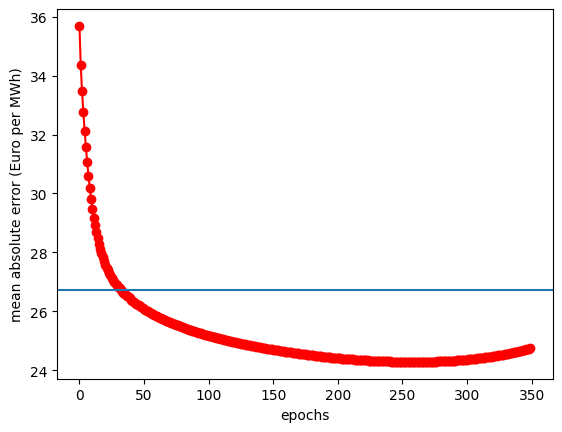

In [385]:
plt.plot(mean_off_list[1:],marker='o',color='red') #ignore the first value which corresponds to the untrained model
mean_abs_off_trivial = evaluate_model_on_dataset(evaluation_data,trivial_model)
print("The trivial model's mean absolute error is",mean_abs_off_trivial)
print("The trained model's mean absolute error is",mean_off_list[-1])
plt.axhline(y=mean_abs_off_trivial,label="trivial model")
plt.xlabel("epochs")
plt.ylabel("mean absolute error (Euro per MWh)")
plt.show()


Finally, we outperform the trivial model after some amount of training, even though only by a tiny bit. Below is a screenshot what happens when the model (with hidden dimension 24) is trained for 1000 epochs

![graph of mean absolute error after thousand epochs](thousand_epochs.png "Mean absolute error after thousand epochs")

More than 400 epochs of training make the model perform worse on the evaluation data, probably because of overfitting to the training data.

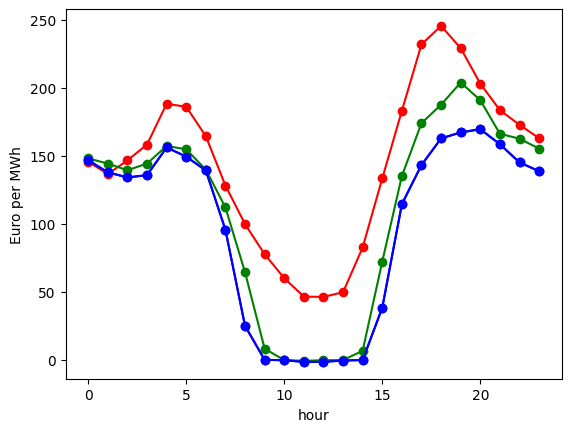

Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).


In [391]:
i = 1
draw_model(evaluation_data,model,offset=i)
draw_model(evaluation_data,trivial_model,offset=i,coloring='green')
plt.show()
print("Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).")

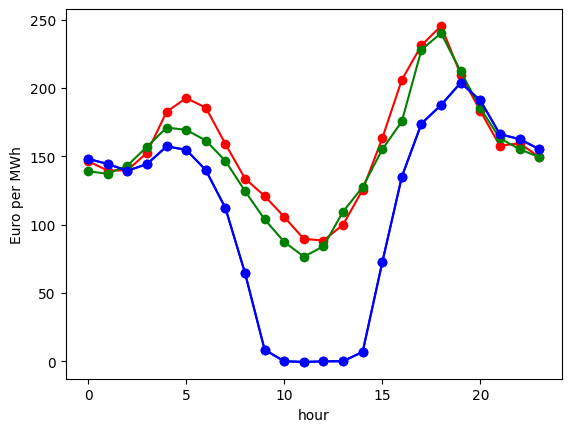

Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).


In [388]:
i = 2
draw_model(evaluation_data,model,offset=i)
draw_model(evaluation_data,trivial_model,offset=i,coloring='green')
plt.show()
print("Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).")

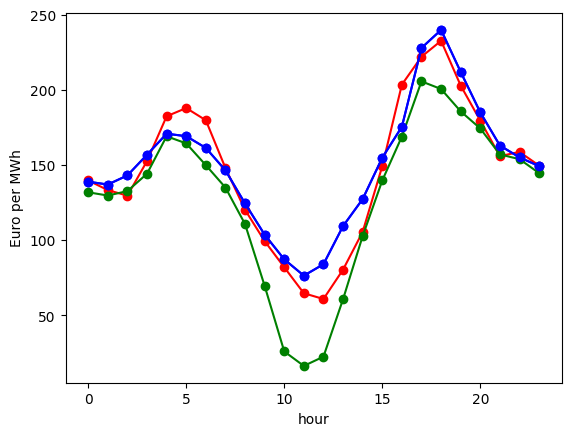

Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).


In [386]:
i = 3
draw_model(evaluation_data,model,offset=i)
draw_model(evaluation_data,trivial_model,offset=i,coloring='green')
plt.show()
print("Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).")

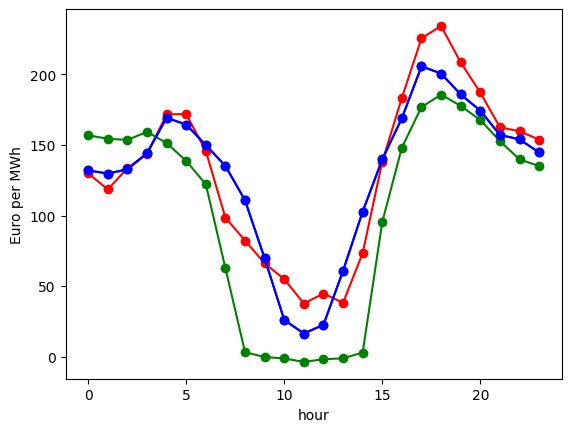

Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).


In [389]:
i = 4
draw_model(evaluation_data,model,offset=i)
draw_model(evaluation_data,trivial_model,offset=i,coloring='green')
plt.show()
print("Comparing the prediction (red), the trivial model's prediction (green) and the actual data (blue).")

 # Conclusion
We have a model that slightly outperforms the trivial model that assumes that today will be the same as yesterday. However, it is still very close to the trivial model, not much better. The main ingredient to improve the model is to include weather forecast data, since generation and therefore prices depend on the weather. We will do that in a later notebook.